In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
r_u = 0
near_u = 0
smote = 2
scaler = 'minmax'
weight_multiplier = 1
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
features_to_remove = ['x', 'y', 'year']
#features_to_remove=[]


In [5]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2011_2022.csv'

dataset = read_data(path)
dataset.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,18.388333,31.078387,41.559495,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.236755,-0.160586,0.085082,-0.085082,0.237146,-0.161234,0.084128,-0.084128,0.031998,0.026201,0.025035,0.025035,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,20.020165,33.195161,41.366925,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.157168,-0.158791,0.026042,-0.026042,0.151596,-0.155242,0.023133,-0.023133,0.023500,0.018424,0.014485,0.014485,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,19.391282,32.160102,40.157912,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.194791,-0.126242,0.069932,-0.069932,0.185733,-0.121223,0.066190,-0.066190,0.038666,0.030799,0.026883,0.026883,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,19.380928,31.921968,39.513355,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.185945,-0.169934,0.034933,-0.034933,0.176351,-0.162109,0.033773,-0.033773,0.025434,0.024895,0.021924,0.021924,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,17.538410,30.001501,42.135300,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.343995,-0.254095,0.089446,-0.089446,0.338470,-0.245319,0.091713,-0.091713,0.033233,0.032721,0.033751,0.033751,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,15911.479310,1


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           351 non-null    int64  
 1   NUTS2_ID       351 non-null    object 
 2   NUTS2_NAME     351 non-null    object 
 3   NUTS3_ID       351 non-null    object 
 4   NUTS3_NAME     351 non-null    object 
 5   x              351 non-null    float64
 6   y              351 non-null    float64
 7   min_temp_q4    351 non-null    float64
 8   mean_temp_q4   351 non-null    float64
 9   max_temp_q4    351 non-null    float64
 10  prec_q4        351 non-null    float64
 11  bio1           351 non-null    float64
 12  bio2           351 non-null    float64
 13  bio3           351 non-null    float64
 14  bio4           351 non-null    float64
 15  bio5           351 non-null    float64
 16  bio6           351 non-null    float64
 17  bio7           351 non-null    float64
 18  bio8      

In [7]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q4', 'mean_temp_q4', 'max_temp_q4', 'prec_q4', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q4', 'ndwi_q4', 'ndmi_q4', 'ndbi_q4', 'ndvi_mean_q4',
       'ndwi_mean_q4', 'ndmi_mean_q4', 'ndbi_mean_q4', 'ndvi_std_q4',
       'ndwi_std_q4', 'ndmi_std_q4', 'ndbi_std_q4', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens', 'WNV_cases'],
      dtype='object')

In [8]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in Attica: 7


In [9]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,0,30,30,8.55%
1,2012,2,45,47,13.39%
2,2013,3,35,38,10.83%
3,2014,6,2,8,2.28%
4,2015,7,0,7,1.99%
5,2016,7,0,7,1.99%
6,2017,7,0,7,1.99%
7,2018,0,155,155,44.16%
8,2019,4,24,28,7.98%
9,2020,6,2,8,2.28%


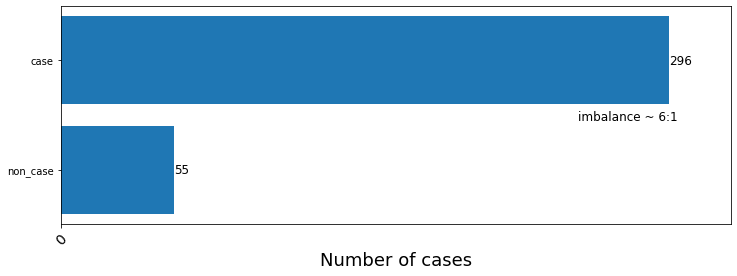

In [10]:
plot_imbalance(dataset, target_column='WNV_cases')

In [11]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] + features_to_remove).columns

In [12]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_train = data_train['WNV_cases']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_test = data_test['WNV_cases']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer = transform_data_new(X_train, X_test, y_train, y_test, r_u, near_u, smote, majority_class = 1, scaler_key=scaler, exclude_features=features_to_remove)
    w0,w1 = calculate_weights_new(y_train)
    w1 = w1*weight_multiplier

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)

    masker = shap.maskers.Independent(data = X_train)
    explainer = shap.LinearExplainer(trained_model, masker = masker)
    shap_values = explainer.shap_values(X_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

Fold: 0 || w0:2, w1:1 || ##
Fold: 1 || w0:2, w1:1 || ##
Fold: 2 || w0:2, w1:1 || ##
Fold: 3 || w0:2, w1:1 || ##
Fold: 4 || w0:2, w1:1 || ##
Fold: 5 || w0:2, w1:1 || ##
Fold: 6 || w0:2, w1:1 || ##
Fold: 7 || w0:2, w1:1 || ##
Fold: 8 || w0:2, w1:1 || ##
Fold: 9 || w0:2, w1:1 || ##


In [13]:
results_test.sort_values(by=['score'], ascending = False, ignore_index = True, inplace = True)

In [14]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,23.889386,38.042726,ανατολικη αττικη,2013,1,0.980046
1,23.889386,38.042726,ανατολικη αττικη,2018,1,0.978403
2,23.889386,38.042726,ανατολικη αττικη,2013,1,0.968661
3,23.889386,38.042726,ανατολικη αττικη,2018,1,0.968290
4,23.393515,38.090792,δυτικη αττικη,2013,0,0.964932
...,...,...,...,...,...,...
185,23.749555,37.914897,νοτιος τομεας αθηνων,2022,0,0.008341
186,23.749555,37.914897,νοτιος τομεας αθηνων,2017,0,0.008255
187,23.209892,37.000012,"πειραιας, νησοι",2020,0,0.007460
188,23.685082,38.018504,δυτικος τομεας αθηνων,2022,0,0.006596


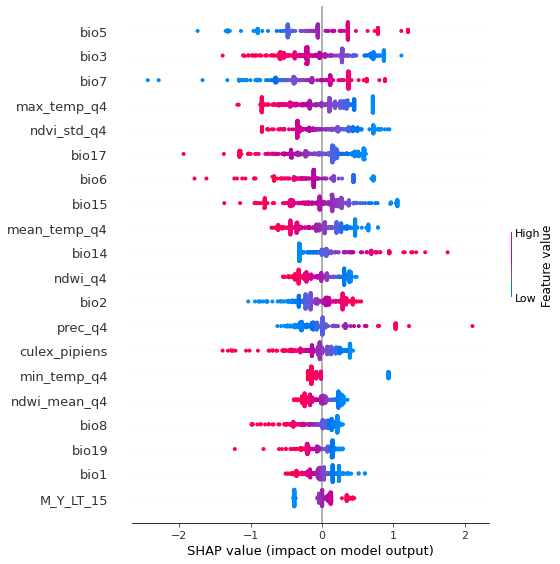

In [15]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names)

In [16]:
shap_values.shape

(414, 47)

In [17]:
feature_names.shape

(47,)

In [18]:
X_train.shape

(414, 47)

In [19]:
mean_shap_values = shap_values.mean(axis=0)

In [20]:
mean_shap_values.shape

(47,)

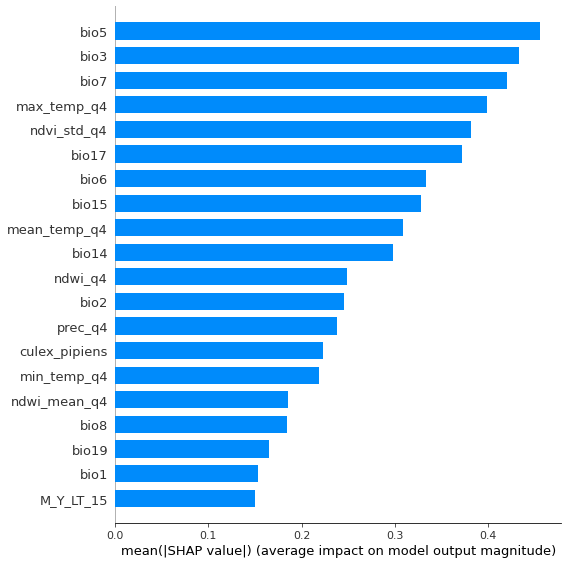

In [21]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar')

In [22]:
mean_shap_values = shap_values.mean(axis=0)

ft_importance = pd.DataFrame()

for i in range(len(feature_names)):
    ft_importance = ft_importance.append({'Feature': feature_names[i],
                                          'Shap': mean_shap_values[i]}, ignore_index = True)

ft_importance.sort_values(by='Shap', key=pd.Series.abs, inplace = True, ascending = False)

ft_importance

,Feature,Shap
10,bio7,-0.042818
5,bio2,-0.037147
9,bio6,-0.036874
6,bio3,0.030249
17,bio14,0.028349
2,max_temp_q4,-0.028134
18,bio15,0.027183
1,mean_temp_q4,-0.020569
22,bio19,-0.016751
3,prec_q4,-0.015735


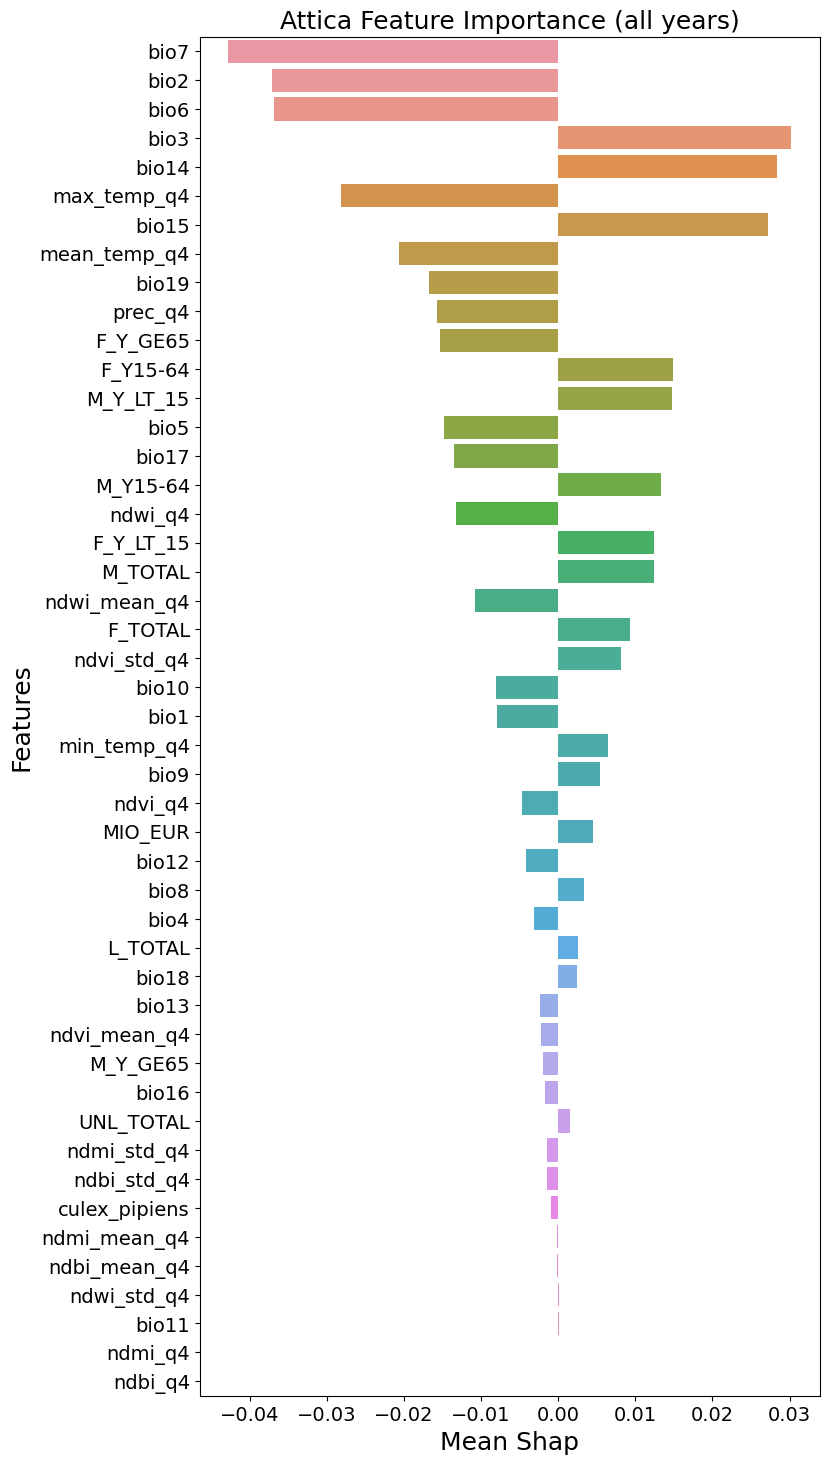

In [23]:
mean_shap = ft_importance['Shap']
shp = mean_shap.shape[0]
mean_shap = mean_shap.to_numpy().reshape(1,shp)

plot_feature_importance(mean_shap, ft_importance['Feature'], x_label = 'Mean Shap', title = f'{NUTS2} Feature Importance (all years)', title_size=18)

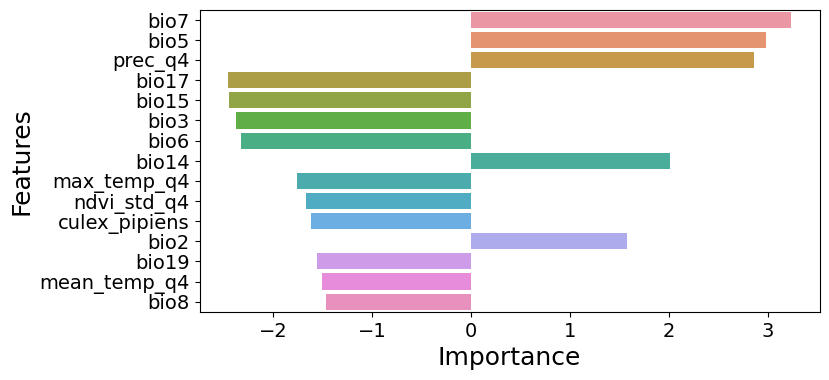

In [24]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

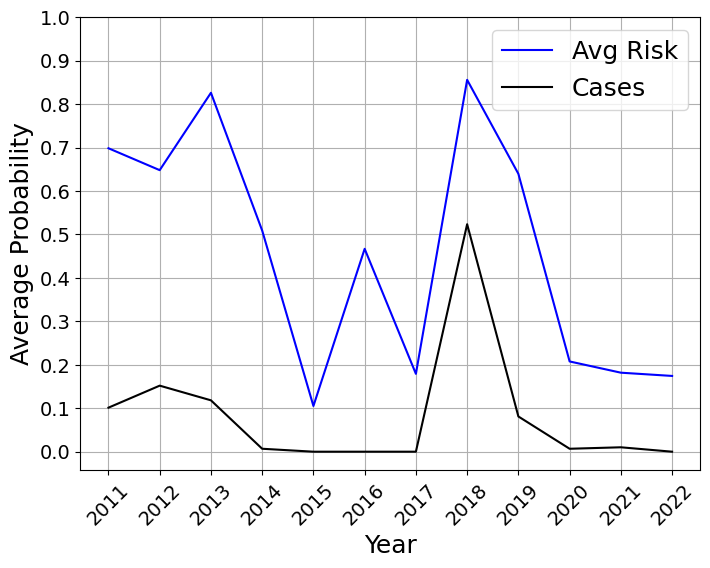

In [25]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

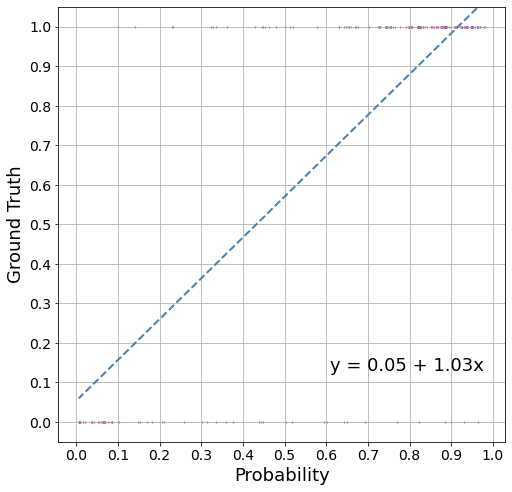

In [26]:
plot_probability_curve(results_test)

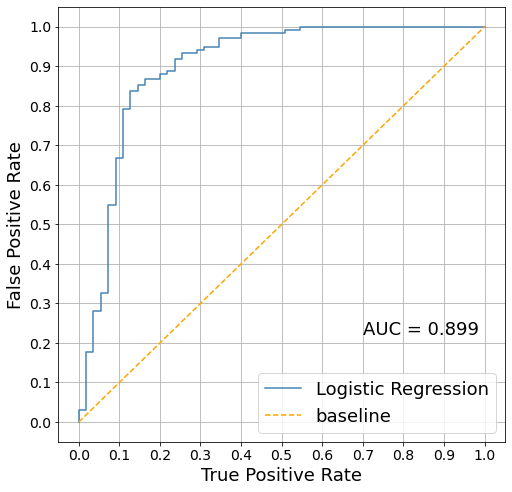

In [27]:
plot_roc_curve(results_test)

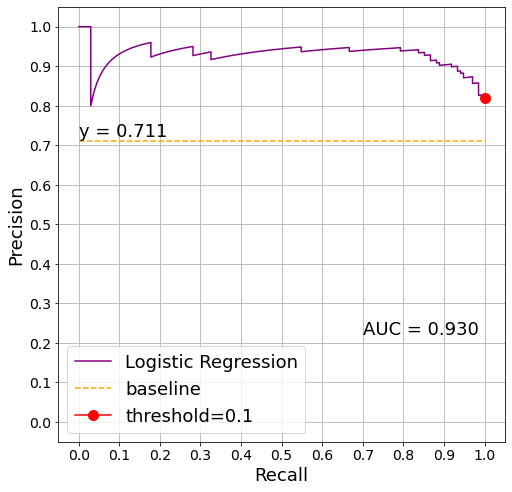

In [28]:
plot_pr_curve(results_test, plot_fbeta=True)

In [29]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,23.889386,38.042726,ανατολικη αττικη,2013,1,0.980046
1,23.889386,38.042726,ανατολικη αττικη,2018,1,0.978403
2,23.889386,38.042726,ανατολικη αττικη,2013,1,0.968661
3,23.889386,38.042726,ανατολικη αττικη,2018,1,0.968290
4,23.393515,38.090792,δυτικη αττικη,2013,0,0.964932
...,...,...,...,...,...,...
185,23.749555,37.914897,νοτιος τομεας αθηνων,2022,0,0.008341
186,23.749555,37.914897,νοτιος τομεας αθηνων,2017,0,0.008255
187,23.209892,37.000012,"πειραιας, νησοι",2020,0,0.007460
188,23.685082,38.018504,δυτικος τομεας αθηνων,2022,0,0.006596


In [30]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [31]:
results_test

,x,y,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,23.889386,38.042726,ανατολικη αττικη,2013,1,0.980046,1,1,1
1,23.889386,38.042726,ανατολικη αττικη,2018,1,0.978403,1,1,1
2,23.889386,38.042726,ανατολικη αττικη,2013,1,0.968661,1,1,1
3,23.889386,38.042726,ανατολικη αττικη,2018,1,0.968290,1,1,1
4,23.393515,38.090792,δυτικη αττικη,2013,0,0.964932,1,1,1
...,...,...,...,...,...,...,...,...,...
185,23.749555,37.914897,νοτιος τομεας αθηνων,2022,0,0.008341,0,0,0
186,23.749555,37.914897,νοτιος τομεας αθηνων,2017,0,0.008255,0,0,0
187,23.209892,37.000012,"πειραιας, νησοι",2020,0,0.007460,0,0,0
188,23.685082,38.018504,δυτικος τομεας αθηνων,2022,0,0.006596,0,0,0


In [32]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
#log_loss_test_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [33]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
#log_loss_test_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [34]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
#log_loss_test_03 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [35]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05}

In [36]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [37]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall
Threshold: 0.1,0.842105,0.727273,0.900000,0.818182,1.000000
Threshold: 0.2,0.863158,0.774411,0.910959,0.847134,0.985185
Threshold: 0.5,0.857895,0.829966,0.899628,0.902985,0.896296
